# Customer Flavour Preference Analysis

This project analyses 245+ customer survey responses collected during the NIFTEM exhibition for Old Batra Lemon.

The objective is to identify:
- Most preferred milk-based flavour
- Most preferred water-based flavour
- Customer rating pattern
- Sugar vs non-sugar preference
- Purchase intent
- Feedback themes
- Final product recommendation

In [1]:
import pandas as pd
import numpy as np


In [2]:
data = pd.read_csv("niftem_synthetic_flavour_survey_245_rows (1).csv")

In [3]:
data

,respondent_id,name,age,gender,location,respondent_type,age_group,best_milk_based_flavor,milk_rating,best_water_based,water_rating_10,sugar_preference,overall_experience_10,purchase_intent,feedback_theme
0,NIFTEM-SYN-001,Ananya Deshmukh,56,Male,Gurugram,Visitor,51+,Mango,9.3,Blueberry,8.4,Sugar,8.8,High,Strong flavour recall
1,NIFTEM-SYN-002,Lakshay Ghosh,23,Male,Lucknow,Student,21-25,Pista,7.7,Blueberry,9.6,Sugar,9.4,High,Good summer refreshment
2,NIFTEM-SYN-003,Devansh Yadav,59,Male,Sonipat,Food Inspector,51+,Butterscotch,8.3,Orange,5.7,Non-sugar,7.3,Medium,Creamy mouthfeel
3,NIFTEM-SYN-004,Lavanya Kulkarni,20,Male,Jaipur,Student,16-20,Rose,6.2,Lemon,7.9,Non-sugar,7.5,Medium,Premium taste perception
4,NIFTEM-SYN-005,Harsh Menon,26,Female,Jaipur,Student,26-35,Butterscotch,7.8,Blueberry,6.9,Sugar,7.4,Medium,Good summer refreshment
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
240,NIFTEM-SYN-241,Felix Fernandez,26,Male,Dubai,Student,26-35,Mango,10.0,Fruit Beer,5.1,Sugar,8.0,High,Creamy mouthfeel
241,NIFTEM-SYN-242,Nikhil Bhatia,23,Female,Sonipat,Student,21-25,Mango,10.0,Orange,5.9,Sugar,8.0,High,Strong flavour recall
242,NIFTEM-SYN-243,Ira Arora,18,Female,Indore,Student,16-20,Mango,8.1,Lemon,10.0,Sugar,9.2,High,Creamy mouthfeel
243,NIFTEM-SYN-244,Simran Yadav,36,Female,Panipat,Food Inspector,36-50,Rose,7.4,Lemon,7.7,Non-sugar,8.1,High,Good summer refreshment


In [4]:
data.head(20)

,respondent_id,name,age,gender,location,respondent_type,age_group,best_milk_based_flavor,milk_rating,best_water_based,water_rating_10,sugar_preference,overall_experience_10,purchase_intent,feedback_theme
0,NIFTEM-SYN-001,Ananya Deshmukh,56,Male,Gurugram,Visitor,51+,Mango,9.3,Blueberry,8.4,Sugar,8.8,High,Strong flavour recall
1,NIFTEM-SYN-002,Lakshay Ghosh,23,Male,Lucknow,Student,21-25,Pista,7.7,Blueberry,9.6,Sugar,9.4,High,Good summer refreshment
2,NIFTEM-SYN-003,Devansh Yadav,59,Male,Sonipat,Food Inspector,51+,Butterscotch,8.3,Orange,5.7,Non-sugar,7.3,Medium,Creamy mouthfeel
3,NIFTEM-SYN-004,Lavanya Kulkarni,20,Male,Jaipur,Student,16-20,Rose,6.2,Lemon,7.9,Non-sugar,7.5,Medium,Premium taste perception
4,NIFTEM-SYN-005,Harsh Menon,26,Female,Jaipur,Student,26-35,Butterscotch,7.8,Blueberry,6.9,Sugar,7.4,Medium,Good summer refreshment
5,NIFTEM-SYN-006,Kabir Mehta,22,Male,Dehradun,Student,21-25,Mango,8.2,Fruit Beer,6.0,Sugar,7.2,Medium,Strong flavour recall
6,NIFTEM-SYN-007,Ritika Bhardwaj,26,Female,Dehradun,Student,26-35,Butterscotch,8.9,Lemon,8.8,Sugar,8.4,High,Creamy mouthfeel
7,NIFTEM-SYN-008,Harsh Chatterjee,22,Male,Patna,Student,21-25,Pista,6.6,Blueberry,8.2,Sugar,7.9,Medium,Balanced sweetness
8,NIFTEM-SYN-009,Aarav Patel,55,Female,Meerut,Visitor,51+,Mango,8.3,Blueberry,7.9,Non-sugar,8.1,High,Strong flavour recall
9,NIFTEM-SYN-010,Selin Novak,53,Male,Kathmandu,Visitor,51+,Mango,7.6,Lemon,10.0,Sugar,8.2,High,Balanced sweetness


In [5]:
data.shape

(245, 15)

This tells how many rows and columns are present in the dataset.
Rows represent survey responses.
Columns represent features like flavour, rating, sugar preference, and purchase intent.

In [6]:
data.columns

Index(['respondent_id', 'name', 'age', 'gender', 'location', 'respondent_type',
       'age_group', 'best_milk_based_flavor', 'milk_rating',
       'best_water_based', 'water_rating_10', 'sugar_preference',
       'overall_experience_10', 'purchase_intent', 'feedback_theme'],
      dtype='object')

In [7]:
data.info() # no null values 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 245 entries, 0 to 244
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   respondent_id           245 non-null    object 
 1   name                    245 non-null    object 
 2   age                     245 non-null    int64  
 3   gender                  245 non-null    object 
 4   location                245 non-null    object 
 5   respondent_type         245 non-null    object 
 6   age_group               245 non-null    object 
 7   best_milk_based_flavor  245 non-null    object 
 8   milk_rating             245 non-null    float64
 9   best_water_based        245 non-null    object 
 10  water_rating_10         245 non-null    float64
 11  sugar_preference        245 non-null    object 
 12  overall_experience_10   245 non-null    float64
 13  purchase_intent         245 non-null    object 
 14  feedback_theme          245 non-null    ob

In [8]:
# Summary of numeric columns like age, milk_rating, water_rating_10, overall_experience_10

data.describe(include="all")

,respondent_id,name,age,gender,location,respondent_type,age_group,best_milk_based_flavor,milk_rating,best_water_based,water_rating_10,sugar_preference,overall_experience_10,purchase_intent,feedback_theme
count,245,245,245.000000,245,245,245,245,245,245.000000,245,245.000000,245,245.000000,245,245
unique,245,245,NaN,3,40,3,5,5,NaN,5,NaN,2,NaN,3,6
top,NIFTEM-SYN-001,Ananya Deshmukh,NaN,Male,Karnal,Student,21-25,Mango,NaN,Lemon,NaN,Sugar,NaN,High,Strong flavour recall
freq,1,1,NaN,130,12,124,78,86,NaN,81,NaN,149,NaN,130,59
mean,NaN,NaN,31.077551,NaN,NaN,NaN,NaN,NaN,8.029796,NaN,7.808980,NaN,7.938776,NaN,NaN
std,NaN,NaN,13.319456,NaN,NaN,NaN,NaN,NaN,1.093146,NaN,1.213315,NaN,0.884849,NaN,NaN
min,NaN,NaN,16.000000,NaN,NaN,NaN,NaN,NaN,4.900000,NaN,4.900000,NaN,5.600000,NaN,NaN
25%,NaN,NaN,21.000000,NaN,NaN,NaN,NaN,NaN,7.300000,NaN,6.900000,NaN,7.300000,NaN,NaN
50%,NaN,NaN,24.000000,NaN,NaN,NaN,NaN,NaN,8.000000,NaN,7.900000,NaN,8.000000,NaN,NaN
75%,NaN,NaN,40.000000,NaN,NaN,NaN,NaN,NaN,8.800000,NaN,8.700000,NaN,8.600000,NaN,NaN


In [9]:
# Check missing values in each column

data.isnull().sum()

respondent_id             0
name                      0
age                       0
gender                    0
location                  0
respondent_type           0
age_group                 0
best_milk_based_flavor    0
milk_rating               0
best_water_based          0
water_rating_10           0
sugar_preference          0
overall_experience_10     0
purchase_intent           0
feedback_theme            0
dtype: int64

The dataset was checked for missing values and no major missing data issue was found.

In [11]:
data.duplicated().sum()

np.int64(0)

In [12]:
total_responses = len(data)

avg_milk_rating = data["milk_rating"].mean()
avg_water_rating = data["water_rating_10"].mean()
avg_overall_experience = data["overall_experience_10"].mean()

print("Total Responses:", total_responses)
print("Average Milk Rating:", round(avg_milk_rating, 2))
print("Average Water Rating:", round(avg_water_rating, 2))
print("Average Overall Experience:", round(avg_overall_experience, 2))

Total Responses: 245
Average Milk Rating: 8.03
Average Water Rating: 7.81
Average Overall Experience: 7.94


The dataset contains 245 responses. The average milk-based rating and water-based rating show that both product categories received strong customer acceptance.

In [13]:
milk_mode = data["best_milk_based_flavor"].mode()[0]
water_mode = data["best_water_based"].mode()[0]
intent_mode = data["purchase_intent"].mode()[0]

print("Most preferred milk-based flavour:", milk_mode)
print("Most preferred water-based flavour:", water_mode)
print("Most common purchase intent:", intent_mode)

Most preferred milk-based flavour: Mango
Most preferred water-based flavour: Lemon
Most common purchase intent: High


SciPy mode was used to find the most common numerical rating. This adds a statistical analysis component to the project.

In [14]:
from scipy import stats

In [15]:
overall_rating_mode = stats.mode(data["overall_experience_10"], keepdims=True)

print("Most common overall experience rating:", overall_rating_mode.mode[0])
print("Frequency:", overall_rating_mode.count[0])

Most common overall experience rating: 8.0
Frequency: 15


In [16]:
from matplotlib import pyplot as plt 


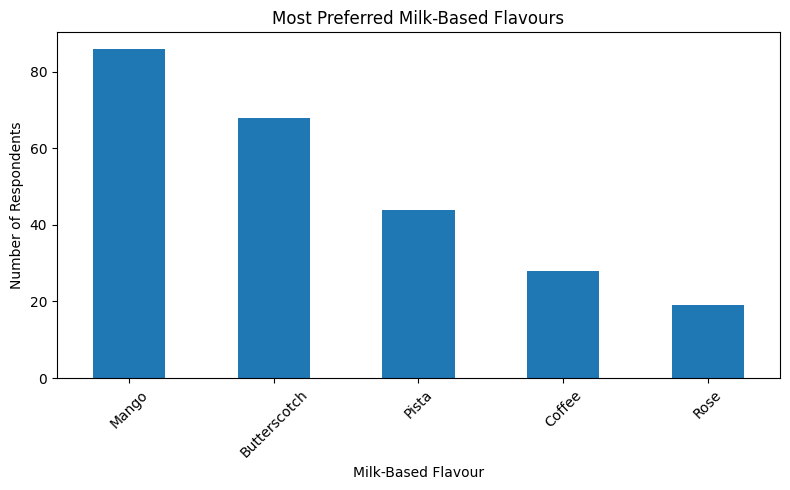

In [22]:
milk_counts = data["best_milk_based_flavor"].value_counts()

plt.figure(figsize=(8, 5))
milk_counts.plot(kind="bar")

plt.title("Most Preferred Milk-Based Flavours")
plt.xlabel("Milk-Based Flavour")
plt.ylabel("Number of Respondents")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Mango received the highest preference among milk-based flavours, followed by Butterscotch. This suggests that Mango has the strongest customer demand in the milk-based category.

## Step 5: Water-Based Flavour Preference

This analysis shows which water-based flavour was selected most frequently by respondents.

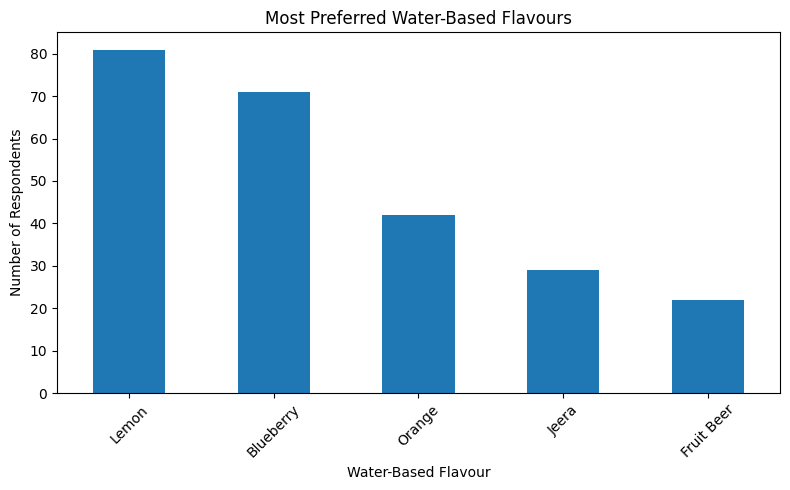

In [24]:
water_counts = data["best_water_based"].value_counts()

plt.figure(figsize=(8, 5))
water_counts.plot(kind="bar")

plt.title("Most Preferred Water-Based Flavours")
plt.xlabel("Water-Based Flavour")
plt.ylabel("Number of Respondents")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Step 6: Average Rating by Flavour

Only counting votes is not enough. A flavour should be both popular and highly rated. Therefore, average rating by flavour is calculated.

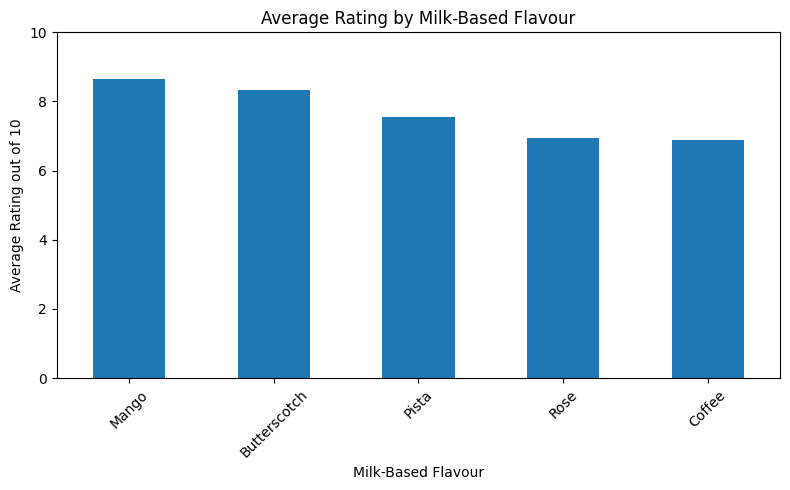

In [25]:
milk_rating_avg = data.groupby("best_milk_based_flavor")["milk_rating"].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
milk_rating_avg.plot(kind="bar")

plt.title("Average Rating by Milk-Based Flavour")
plt.xlabel("Milk-Based Flavour")
plt.ylabel("Average Rating out of 10")
plt.ylim(0, 10)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Mango achieved the highest average rating among milk-based flavours. This confirms that Mango is not only popular by count but also strong in customer satisfaction.

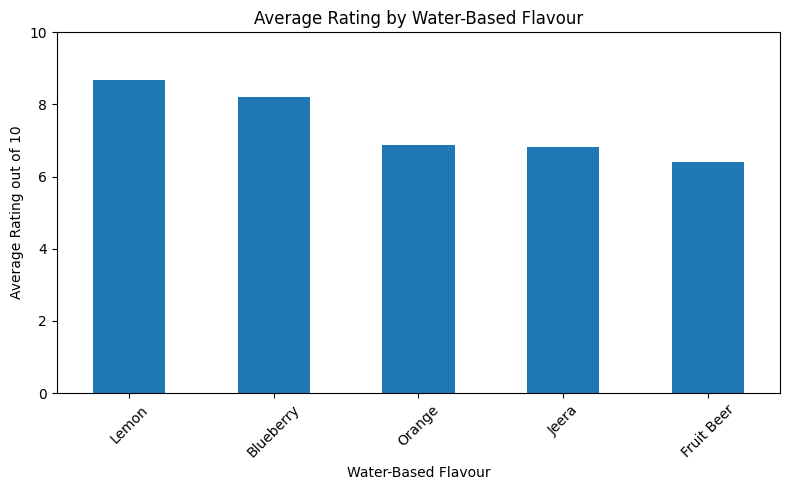

In [26]:
water_rating_avg = data.groupby("best_water_based")["water_rating_10"].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
water_rating_avg.plot(kind="bar")

plt.title("Average Rating by Water-Based Flavour")
plt.xlabel("Water-Based Flavour")
plt.ylabel("Average Rating out of 10")
plt.ylim(0, 10)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Lemon achieved the highest average rating among water-based flavours. This supports Lemon as the most reliable flavour for product positioning and launch planning.

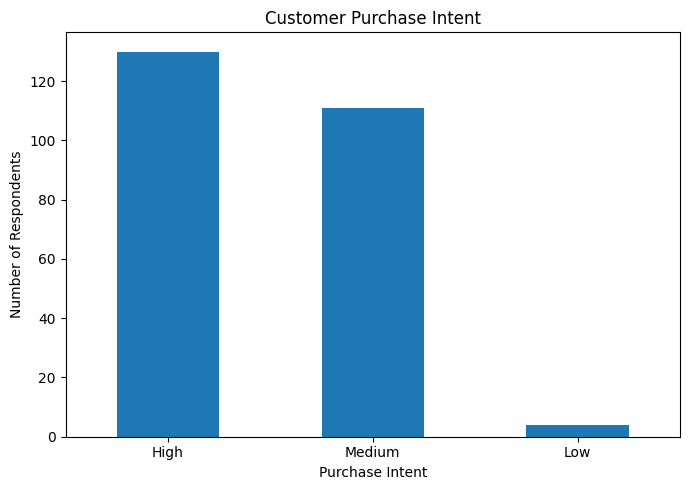

In [28]:
purchase_counts = data["purchase_intent"].value_counts()

plt.figure(figsize=(7, 5))
purchase_counts.plot(kind="bar")

plt.title("Customer Purchase Intent")
plt.xlabel("Purchase Intent")
plt.ylabel("Number of Respondents")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

The majority of respondents showed High or Medium purchase intent, while only a very small number showed Low intent. This indicates strong customer acceptance and good market potential.

## Step 8: Sugar vs Non-Sugar Preference

This analysis helps understand whether customers prefer regular sugar-based products or non-sugar alternatives.

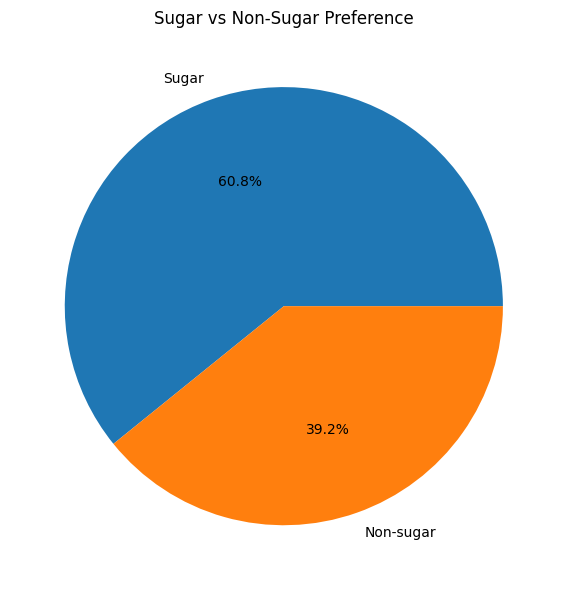

In [ ]:
sugar_counts = data["sugar_preference"].value_counts()

plt.figure(figsize=(6, 6))
sugar_counts.plot(kind="pie", autopct="%1.1f%%")

plt.title("Sugar vs Non-Sugar Preference")
plt.ylabel("")
plt.tight_layout()
plt.show()

Most respondents preferred sugar-based options, but a significant group also preferred non-sugar variants. This suggests that the brand can target both regular consumers and health-conscious customers.

## Step 9: Feedback Theme Analysis

Feedback theme analysis converts customer opinion into business insights. It helps identify what customers liked or wanted to improve.

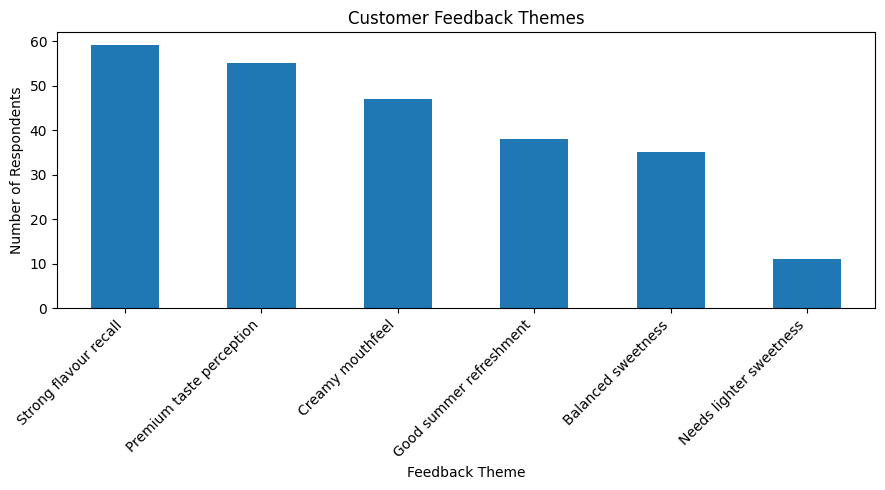

In [31]:
feedback_counts = data["feedback_theme"].value_counts()

plt.figure(figsize=(9, 5))
feedback_counts.plot(kind="bar")

plt.title("Customer Feedback Themes")
plt.xlabel("Feedback Theme")
plt.ylabel("Number of Respondents")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Step 10: Correlation Analysis

Correlation analysis is used to understand the relationship between numerical rating columns.

In [33]:
import seaborn as sns

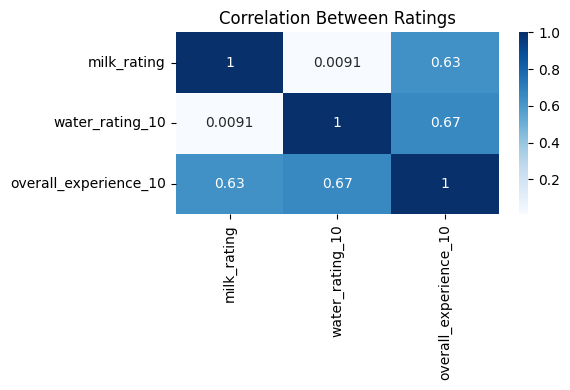

In [34]:
rating_corr = data[["milk_rating", "water_rating_10", "overall_experience_10"]].corr()

plt.figure(figsize=(6, 4))
sns.heatmap(rating_corr, annot=True, cmap="Blues")

plt.title("Correlation Between Ratings")
plt.tight_layout()
plt.show()

## Step 11: Final Flavour Recommendation

In this step, both total votes and average rating are considered together. This gives a better recommendation than using only popularity count.

In [36]:
milk_summary = data.groupby("best_milk_based_flavor").agg(
    total_votes=("best_milk_based_flavor", "count"),
    average_rating=("milk_rating", "mean")
).sort_values(by=["total_votes", "average_rating"], ascending=False)

water_summary = data.groupby("best_water_based").agg(
    total_votes=("best_water_based", "count"),
    average_rating=("water_rating_10", "mean")
).sort_values(by=["total_votes", "average_rating"], ascending=False)

print("Milk-Based Flavour Summary")
display(milk_summary)

print("Water-Based Flavour Summary")
display(water_summary)

Milk-Based Flavour Summary


,total_votes,average_rating
best_milk_based_flavor,,
Mango,86,8.641860
Butterscotch,68,8.342647
Pista,44,7.554545
Coffee,28,6.878571
Rose,19,6.936842


Water-Based Flavour Summary


,total_votes,average_rating
best_water_based,,
Lemon,81,8.686420
Blueberry,71,8.209859
Orange,42,6.866667
Jeera,29,6.813793
Fruit Beer,22,6.395455


# Final Business Conclusion

The analysis of 245+ customer survey responses shows that Mango and Lemon are the strongest flavour candidates.

Mango performed best in the milk-based category, while Lemon performed best in the water-based category. Blueberry also showed strong potential as a secondary water-based flavour.

The purchase intent analysis shows strong customer acceptance, with most respondents showing High or Medium purchase intent. Feedback theme analysis also shows positive customer response, especially in terms of flavour recall and premium taste perception.

This project demonstrates how raw customer feedback can be converted into actionable business insights using Python-based data analysis.